**Objective:**

In this investigation,  the goal is to evaluate how fulfillment performance influences customer satisfaction and identify whether seller performance represents a meaningful opportunity for improving the customer experience. My Product Manager, Sarah, has more questions based on Notebook 03's investigations.

**Analyst Commentary**

Sarah's third question: Do longer delivery times affect customer satisfaction?

**Planning**

*Business Question:* Do longer delivery times affect customer satisfaction?

*Metric:*
* Dependent variable: Customer satisfaction (review_score)
* Independent variable: `days_late` (primary predictor)
* `delivery_time_days` (secondary predictor)

*Comparison:* Compare `review_score` across different values of `days_late` to determine whether customers who receive late deliveries tend to leave lower ratings than customers whose orders arrive on time or early.

*Limitation:* This investigation can identify associations between delivery performance and customer satisfaction but cannot establish causation because other factors may also influence review scores.

*Visualization:* Bar chart
*  X-axis: `days_late` buckets (Early, On Time, 1-2 Days Late, 3-5 Days Late, 6+ Days late)
*  Y-axis: Average review score

*Interpretation:*

Do customers who receive late deliveries leave lower review scores?

Is the relationship strong or weak?

Are there any unexpected patterns?

Does meeting or exceeding the estimated delivery date appear to improve customer satisfaction?

Additional Notes:

Primary Analysis: `days_late` because it reflects whether customer expectations were met.

Supporting Analysis: `delivery_time_days` to determine whether the total wait time has an additional relationship with customer satisfaction.

In [ ]:
# Importing tables needed for this investigation

import pandas as pd

order_reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("orders_clean.csv")

order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


**Auditing the Order Reviews Table**

In [ ]:
# Number of rows/columns

order_reviews.shape

(99224, 7)

**Analyst Commentary**

The table contains over 99,000 reviews, providing sufficient observations for analyzing the relationship between delivery performance and customer satisfaction.

In [ ]:
# Datatypes

order_reviews.dtypes

,0
review_id,object
order_id,object
review_score,int64
review_comment_title,object
review_comment_message,object
review_creation_date,object
review_answer_timestamp,object


**Analyst Commentary**

Since the investigation is focusing on the `review_score` field, `review_create_date` and `review_answer_timestamp` do not need to be changed to `datetime` unless the investigation reveals that time-series analysis is needed.

The primary key is unique (`review_id`).

`order_id` is the key that matters for this investigation since we are joining the order_reviews table with the orders table using `order_id`.

In [ ]:
# Checking for missing values

order_reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


**Analyst Commentary**

There are missing values in the `review_comment_title` coloumn and the `review_comment_message` column. Since this investigation measures customer satisfaction using the numerical `review_score`, missing review titles and messages do not affect the primary analysis. However, they would become important if we later performed sentiment or text analysis.

In addition, the missing data can also suggest that a review score was given but there was no commentary. This is possible as reviews do not necessarily require comments. Would be great to verify if all the rows in the order reviews table have a `review_score`.

In [ ]:
# Are there null values in review_score?

order_reviews["review_score"].isnull().sum()

np.int64(0)

In [ ]:
# What's the distribution of review scores?

order_reviews["review_score"].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


**Analyst Commentary**

Each row has a corresponding `review_score`, and the distribution of scores ranges from 1 to 5.

In [ ]:
# Checking for duplicate rows

order_reviews.duplicated().sum()

np.int64(0)

In [ ]:
# See duplicated rows

order_reviews[order_reviews.duplicated()]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [ ]:
# Get statistical summary (spot outliers/weird ranges)

order_reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Analyst Commentary**

Because the business question deals with customer satisfaction, the `review_score` column will be the important variable I will keep for this analysis.

In [ ]:
# Checking for duplicate order_id

order_reviews["order_id"].duplicated().sum()

np.int64(551)

**Analyst Commentary**

There are 551 duplicate order IDs. Need to determine whether if these are genuine duplicated rows or if these are multiple reviews for the same `order_id`.

In [ ]:
# Addressing the 551 duplicate order_id

# Are these duplicate rows or are these multiple reviews for the same order?

order_reviews[order_reviews.duplicated(subset=["order_id"], keep=False)].sort_values("order_id")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
...,...,...,...,...,...,...,...
27465,5e78482ee783451be6026e5cf0c72de1,ff763b73e473d03c321bcd5a053316e8,3,NaN,Não sei que haverá acontecido os demais chegaram,2017-11-18 00:00:00,2017-11-18 09:02:48
41355,39de8ad3a1a494fc68cc2d5382f052f4,ff850ba359507b996e8b2fbb26df8d03,5,NaN,Envio rapido... Produto 100%,2017-08-16 00:00:00,2017-08-17 11:56:55
18783,80f25f32c00540d49d57796fb6658535,ff850ba359507b996e8b2fbb26df8d03,5,NaN,"Envio rapido, produto conforme descrito no anu...",2017-08-22 00:00:00,2017-08-25 11:40:22
92230,870d856a4873d3a67252b0c51d79b950,ffaabba06c9d293a3c614e0515ddbabc,3,NaN,NaN,2017-12-20 00:00:00,2017-12-20 18:50:16


In [ ]:
# Count how many times each specific value is duplicated

order_reviews["order_id"].value_counts()[order_reviews["order_id"].value_counts() > 1]

,count
order_id,
03c939fd7fd3b38f8485a0f95798f1f6,3
8e17072ec97ce29f0e1f111e598b0c85,3
c88b1d1b157a9999ce368f218a407141,3
df56136b8031ecd28e200bb18e6ddb2e,3
843be4a0dcdb9716de7652d53af4acab,2
...,...
fd61441ba2a7b57e6342862e779b10b0,2
4703440eb9289d3769819920e98ec061,2
3c5c2cfeea91d9a57ac3c979ec6c9d62,2


In [ ]:
# Check which columns actually differ between duplicate rows

dupes = order_reviews[order_reviews.duplicated(subset=["order_id"], keep=False)].sort_values("order_id")

dupes.groupby("order_id").nunique()

,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
order_id,,,,,,
0035246a40f520710769010f752e7507,2,1,0,1,2,2
013056cfe49763c6f66bda03396c5ee3,2,2,0,0,2,2
0176a6846bcb3b0d3aa3116a9a768597,2,1,0,0,1,2
02355020fd0a40a0d56df9f6ff060413,2,2,0,2,2,2
029863af4b968de1e5d6a82782e662f5,2,2,0,0,2,2
...,...,...,...,...,...,...
fd95ae805c63c534f1a64589e102225e,2,1,0,2,2,2
fe041ba1c9f54016432fa6ee91709dbc,2,1,0,1,1,2
ff763b73e473d03c321bcd5a053316e8,2,2,0,1,2,2


In [ ]:
# Compare two duplicate counts against each other

full_row_dupes = order_reviews.duplicated().sum()
id_dupes = order_reviews.duplicated(subset=["order_id"], keep=False).sum()

print(f"Full-row duplicates: {full_row_dupes}")
print(f"Rows sharing an order_id: {id_dupes}")

Full-row duplicates: 0
Rows sharing an order_id: 1098


**Analyst Commentary**

The duplicate order IDs represent multiple reviews. I am leaning towards keeping the data, as they are unique, by their `review_answer_timestamp` column. If multiple reviews are retained for the same order, those orders will contribute more then once to the analysis. Each order has to have one, clear `review_score`. This could bias summary statistics and any observed relationship between delivery performance and customer satisfaction. If these particular records aren't kept, then I will be missing out on insights for future analysis, such as text analysis.

**Business Rule 1:** For orders with multiple reviews, retain the most recent review based on `review_answer_timestamp`. This ensures each order contributes one final customer satisfaction score to the analysis. This business rule was applied only for this investigation. The original order reviews table remains unchanged for future analyses.


**Cleaning Order Reviews Table**

In [ ]:
# Convert required rows from string to datetime and verify

order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"], errors="coerce")
order_reviews["review_answer_timestamp"] = pd.to_datetime(order_reviews["review_answer_timestamp"], errors="coerce")

order_reviews.dtypes



,0
review_id,object
order_id,object
review_score,int64
review_comment_title,object
review_comment_message,object
review_creation_date,datetime64[ns]
review_answer_timestamp,datetime64[ns]


**Joining Two Tables with Established Business Rule**

In [ ]:
# Create analysis dataset

reviews_final = (order_reviews.sort_values("review_answer_timestamp").drop_duplicates(subset="order_id", keep="last"))

reviews_final


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
37547,6916ca4502d6d3bfd39818759d55d536,bfbd0f9bdef84302105ad712db648a6c,1,NaN,nao recebi o produto e nem resposta da empresa,2016-10-06 00:00:00,2016-10-07 18:32:28
5503,49f695dffa457eaba90d388a5c37e942,e5215415bb6f76fe3b7cb68103a0d1c0,1,NaN,"PRODUTO NÃO CHEGOU,E JÁ PASSOU O PRAZO DE ENTREGA",2016-10-09 00:00:00,2016-10-11 14:31:29
60439,743d98b1a4782f0646898fc915ef002a,e2144124f98f3bf46939bc5183104041,4,NaN,NaN,2016-10-15 00:00:00,2016-10-16 03:20:17
28075,53752edb26544dd41c1209f582c9c589,b8b9d7046c083150cb5360b83a8ebb51,5,NaN,O pedido foi entregue antes do prazo pr0metido,2016-10-16 01:00:00,2016-10-16 15:45:11
41042,b2d5d8db2a841d27a72e4c06c6212368,9aa3197e4887919fde0307fc23601d7a,4,NaN,Só chegou uma parte do pedido ate agora..,2016-10-15 00:00:00,2016-10-17 21:02:49
...,...,...,...,...,...,...,...
46904,6c50d16eb583d5db7e841b77e89b7045,0b223d92c27432930dfe407c6aea3041,5,NaN,NaN,2018-08-31 00:00:00,2018-10-24 16:27:36
14687,abf08328d2f1f0e8a33eee9f52f502f6,99e4a1f9377bf28f08f54a2eecccbf0d,5,NaN,NaN,2018-02-02 00:00:00,2018-10-24 18:26:25
92802,6c883909cf53725a13caf477a70f00a4,7ce4e38f4eadd993bb5b2e60bb7f7bec,5,Muito bonita,"Amei a mesinha, que pena que me confundir na c...",2018-08-16 00:00:00,2018-10-24 21:34:38
49615,728d5cfdc7283cfd0a8061d7581a19f8,7e8072dc0f35ebb0c1b2a4743e0f179a,5,NaN,NaN,2018-07-12 00:00:00,2018-10-26 21:36:41


In [ ]:
# How many rows did order_reviews have originally?

order_reviews.shape

(99224, 7)

In [ ]:
# How many rows did orders have originally?

orders.shape

(99441, 19)

In [ ]:
# How many rows does reviews_final have after applying your business rule?

reviews_final.shape

(98673, 7)

In [ ]:
# Join the orders and order_reviews tables using order_id

reviews_analysis_df = orders.merge(reviews_final, on="order_id", how="inner")

In [ ]:
# How many rows are in the joined dataset

reviews_analysis_df.shape

(98673, 25)

In [ ]:
# Is there exactly one row per order?

reviews_analysis_df["order_id"].is_unique

True

In [ ]:
# Saved joined DataFrame

reviews_analysis_df.to_csv("reviews_analysis_df.csv", index=False)

**Analyst Commentary**

Now that the orders and order reviews tables have been joined successfully, the next step is to investigate Sarah's question.

In [ ]:
# Summary Statistics

reviews_analysis_df[['review_score', 'days_late', 'delivery_time_days']].describe()

,review_score,days_late,delivery_time_days
count,98673.000000,95830.000000,95830.000000
mean,4.086386,-11.913263,12.053522
std,1.347618,10.112524,9.466266
min,1.000000,-147.000000,0.000000
25%,4.000000,-17.000000,6.000000
50%,5.000000,-12.000000,10.000000
75%,5.000000,-7.000000,15.000000
max,5.000000,188.000000,208.000000


**Analyst Commentary**

Contextually, a negative value indicates that deliveries have made it to the customer on time or earlier than anticipated.

Maximum number of `days_late` is 188 (which was flagged in Notebook 02). Worth investigating what is going on with orders where days_late is around the maximum value to see if there are any trends.


In [ ]:
# Investigating where days_late > 100

reviews_analysis_df[reviews_analysis_df["days_late"] > 100]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,approval_time_hours,...,purchase_month_name,purchase_quarter,purchase_weekday,order_month,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3179,4f39a94d6e474819d898d6df7d394996,27a410dccb395b6ce45963874d158352,delivered,2017-04-28 16:28:03,2017-04-29 02:42:51,2017-05-09 14:06:48,2017-09-19 13:54:18,2017-05-30,143.0,10.246667,...,April,2,Friday,2017-04-01,305f7cbe3fcbe1bfd677c375b4134b65,2,NaN,Entrega dentro do prazo porem em um determinad...,2017-05-26,2017-05-29 11:23:51
4633,b31c7dea63bb08f8cdd1ec32514ccf0b,2a351c540a0cbdd0d9c266626f6d3acc,delivered,2017-09-26 18:35:35,2017-09-26 18:49:09,2017-09-29 16:23:06,2018-02-05 21:25:43,2017-10-19,132.0,0.226111,...,September,3,Tuesday,2017-09-01,9993e6c02dccdb3e92a6566c64ad779f,1,NaN,Não recebi o rpoduto em minha residencia.,2017-10-21,2017-10-22 20:48:57
11334,47b40429ed8cce3aee9199792275433f,cb2caaaead400c97350c37a3fc536867,delivered,2018-01-03 09:44:01,2018-01-03 10:31:15,2018-02-06 01:48:28,2018-07-13 20:51:31,2018-01-19,191.0,0.787222,...,January,1,Wednesday,2018-01-01,2a87b7df4f64481f0db340b1196ab9fc,1,NaN,Gostaria de saber o que aconteceu o prazo que ...,2018-01-21,2018-01-24 16:45:40
12739,c2a550cc5f966506b717532441c221e5,fc99aeadad12e8925f558305956a08aa,delivered,2018-01-12 15:38:34,2018-01-13 15:33:31,2018-01-15 15:46:55,2018-05-23 20:56:25,2018-02-08,131.0,23.915833,...,January,1,Friday,2018-01-01,791794735a2f3b5784056eae747e86a5,1,NaN,Não recebi meu produto,2018-02-11,2018-02-11 07:07:55
16846,cce224811ba8fea016c049693c3e0402,919dc37f94a27a8b5cac7fd53291afd4,delivered,2018-02-28 12:30:39,2018-02-28 12:48:38,2018-03-02 18:11:39,2018-07-26 16:41:56,2018-03-22,148.0,0.299722,...,February,1,Wednesday,2018-02-01,46e32ee94b17dc3adbdb2e786f289572,4,NaN,Sempre cumprem os prazos. Muito bom.,2018-03-24,2018-03-29 16:57:09
29071,6e6527028de694ccade37f5a15a6d84a,a48d74b7c46f9ee06e4ca93cae7b598f,delivered,2017-11-25 23:51:54,2017-11-25 23:59:27,2017-11-28 17:11:21,2018-05-10 00:06:20,2017-12-18,165.0,0.125833,...,November,4,Saturday,2017-11-01,973acaadf9fb05a5c8be5540310c795e,1,NaN,Estou aguando o meu produto que não chegou den...,2017-12-19,2017-12-19 13:11:18
29322,4fbc8d6f2f4db3e789d5a876fa349b56,bf391aa5a48fbaee55092f1993be3926,delivered,2018-02-02 21:38:36,2018-02-03 20:10:18,2018-02-08 01:04:18,2018-07-20 23:37:50,2018-03-08,168.0,22.528333,...,February,1,Friday,2018-02-01,6d47cae89d41ded757942747d47632ef,5,NaN,"O Produto é muito bom e Bonito, recebe antes d...",2018-03-11,2018-03-11 03:48:54
31013,dfe5f68118c2576143240b8d78e5940a,8f6ceed676a529b29619a598b377de08,delivered,2017-03-17 12:32:22,2017-03-17 12:32:22,2017-03-21 18:28:04,2017-09-19 18:13:19,2017-04-19,186.0,0.000000,...,March,1,Friday,2017-03-01,07d5dcbf44b0fb418dce274ed67a905c,4,NaN,a espera do reembolso. ou cancelarei o pagamento,2017-04-21,2017-04-24 12:20:46
34020,c5f43352377291361dad9a7366ae1c89,f9796700c0a1d4455471776293bbbc09,delivered,2017-11-22 14:15:15,2017-11-22 21:48:22,2017-11-27 18:57:23,2018-04-06 21:52:36,2017-12-18,135.0,7.551944,...,November,4,Wednesday,2017-11-01,538cb5e6d0ffa67a8d7d856f860b4513,5,NaN,NaN,2017-12-19,2017-12-21 03:16:07
35805,e7fc47a9bd5fd8c1d1b566d1553be0f4,de933a935e7c75c60cf44b12e0972268,delivered,2017-05-25 09:59:33,2017-05-25 10:10:14,2017-05-30 15:01:07,2017-09-19 13:38:16,2017-06-07,117.0,0.178056,...,May,2,Thursday,2017-05-01,f751740c9bf83c898223d2dbacc820fb,1,NaN,se não tem estoque não poderia ter a opção de ...,2017-06-09,2017-06-09 18:08:15


In [ ]:
# Looking at the full context of these rows

reviews_analysis_df[reviews_analysis_df["days_late"] > 100][
    ["order_id", "days_late", "delivery_time_days", "order_purchase_timestamp",
     "order_delivered_customer_date", "order_estimated_delivery_date"]
]

,order_id,days_late,delivery_time_days,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
3179,4f39a94d6e474819d898d6df7d394996,112.0,143.0,2017-04-28 16:28:03,2017-09-19 13:54:18,2017-05-30
4633,b31c7dea63bb08f8cdd1ec32514ccf0b,109.0,132.0,2017-09-26 18:35:35,2018-02-05 21:25:43,2017-10-19
11334,47b40429ed8cce3aee9199792275433f,175.0,191.0,2018-01-03 09:44:01,2018-07-13 20:51:31,2018-01-19
12739,c2a550cc5f966506b717532441c221e5,104.0,131.0,2018-01-12 15:38:34,2018-05-23 20:56:25,2018-02-08
16846,cce224811ba8fea016c049693c3e0402,126.0,148.0,2018-02-28 12:30:39,2018-07-26 16:41:56,2018-03-22
29071,6e6527028de694ccade37f5a15a6d84a,143.0,165.0,2017-11-25 23:51:54,2018-05-10 00:06:20,2017-12-18
29322,4fbc8d6f2f4db3e789d5a876fa349b56,134.0,168.0,2018-02-02 21:38:36,2018-07-20 23:37:50,2018-03-08
31013,dfe5f68118c2576143240b8d78e5940a,153.0,186.0,2017-03-17 12:32:22,2017-09-19 18:13:19,2017-04-19
34020,c5f43352377291361dad9a7366ae1c89,109.0,135.0,2017-11-22 14:15:15,2018-04-06 21:52:36,2017-12-18
35805,e7fc47a9bd5fd8c1d1b566d1553be0f4,104.0,117.0,2017-05-25 09:59:33,2017-09-19 13:38:16,2017-06-07


In [ ]:
#Check relationship between days_late and delivery_time_days

reviews_analysis_df[["order_id", "days_late", "delivery_time_days"]]

,order_id,days_late,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,2.0
...,...,...,...
98668,9c5dedf39a927c1b2549525ed64a053c,-11.0,8.0
98669,63943bddc261676b46f01ca7ac2f7bd8,-2.0,22.0
98670,83c1379a015df1e13d02aae0204711ab,-6.0,24.0
98671,11c177c8e97725db2631073c19f07b62,-21.0,17.0


In [ ]:
# Convert text to datetimes
reviews_analysis_df["order_delivered_customer_date"] = pd.to_datetime(
    reviews_analysis_df["order_delivered_customer_date"], errors="coerce"
)
reviews_analysis_df["order_estimated_delivery_date"] = pd.to_datetime(
    reviews_analysis_df["order_estimated_delivery_date"], errors="coerce"
)

In [ ]:
# Verify the date logic directly

check = reviews_analysis_df[reviews_analysis_df["days_late"] > 100].copy()
check["recalculated_days_late"] = (check["order_delivered_customer_date"] - check["order_estimated_delivery_date"]).dt.days
check[["order_id", "days_late", "recalculated_days_late", "delivery_time_days"]]

,order_id,days_late,recalculated_days_late,delivery_time_days
3179,4f39a94d6e474819d898d6df7d394996,112.0,112,143.0
4633,b31c7dea63bb08f8cdd1ec32514ccf0b,109.0,109,132.0
11334,47b40429ed8cce3aee9199792275433f,175.0,175,191.0
12739,c2a550cc5f966506b717532441c221e5,104.0,104,131.0
16846,cce224811ba8fea016c049693c3e0402,126.0,126,148.0
29071,6e6527028de694ccade37f5a15a6d84a,143.0,143,165.0
29322,4fbc8d6f2f4db3e789d5a876fa349b56,134.0,134,168.0
31013,dfe5f68118c2576143240b8d78e5940a,153.0,153,186.0
34020,c5f43352377291361dad9a7366ae1c89,109.0,109,135.0
35805,e7fc47a9bd5fd8c1d1b566d1553be0f4,104.0,104,117.0


**Analyst Commentary**

37 orders (0.04% of records) experienced extreme delivery delays (100+ days past estimate). Verified as accurate via cross-checking against delivery_time_days and raw date recalculation. Recommend investigating root cause (carrier, warehouse, or regional issue) separately from this investigation.

In [ ]:
# Create delivery buckets

import numpy as np

reviews_analysis_df["days_late_category"] = pd.cut(
    reviews_analysis_df["days_late"],
    bins=[-np.inf, -17, -7, 0, 7, np.inf],
    labels=["Very Early", "Early", "On Time/Slightly Early", "Slightly Late", "Very Late"]
)

In [ ]:
# Verify if the bins reflect the data reasonably

reviews_analysis_df["days_late_category"].value_counts().sort_index()

,count
days_late_category,
Very Early,25566
Early,50183
On Time/Slightly Early,13699
Slightly Late,3600
Very Late,2782


In [ ]:
# Calculate average and median review scores by bin

reviews_analysis_df.groupby("days_late_category", observed=True)["review_score"].agg(["mean", "median"])

,mean,median
days_late_category,,
Very Early,4.316240,5.0
Early,4.311062,5.0
On Time/Slightly Early,4.165487,5.0
Slightly Late,2.714167,3.0
Very Late,1.696621,1.0


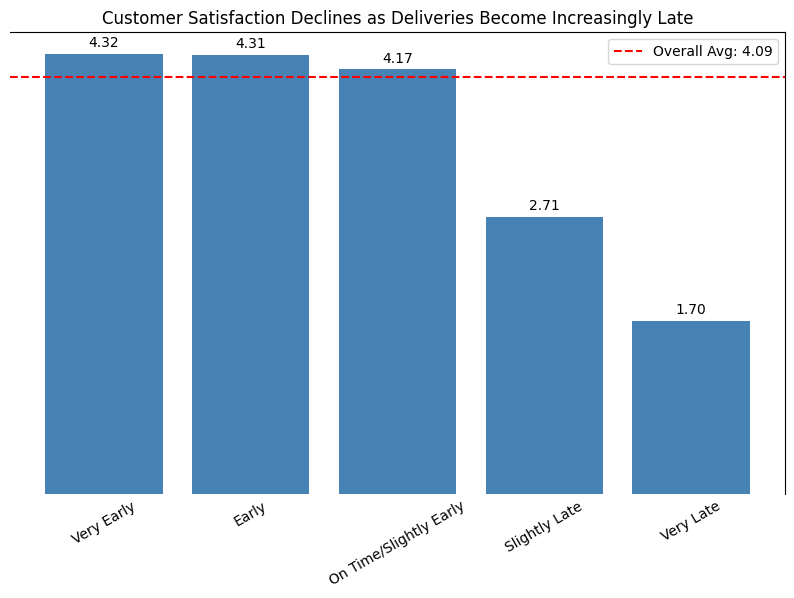

In [ ]:
# Bar plot on average review_scores by bin

import matplotlib.pyplot as plt

avg_scores = reviews_analysis_df.groupby("days_late_category", observed=True)["review_score"].agg(["mean"])
overall_avg = reviews_analysis_df["review_score"].mean()

plt.figure(figsize=(10, 6))
bars = plt.bar(avg_scores.index, avg_scores["mean"], color="steelblue")
plt.axhline(overall_avg, color="red", linestyle="--", label=f"Overall Avg: {overall_avg:.2f}")
plt.title("Customer Satisfaction Declines as Deliveries Become Increasingly Late")
plt.xticks(rotation=30)
plt.legend()

ax = plt.gca()
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)
ax.set_yticklabels([])
plt.grid(False)

ax.bar_label(bars, fmt="%.2f", padding=3)

plt.show()

**Analyst Commentary**

Orders delivered several days after the estimated delivery date consistently received lower average review scores than orders delivered on time or early. This suggests that failing to meet delivery expectations is associated with reduced customer satisfaction. In addition, there are 37 orders where deliveries are over 100 days late. Further investigation on what particular bottleneck may be the cause would be the next step.

**Business Recommendation**

Prioritize operational improvements that reduce late deliveries, particularly for orders exceeding the estimated delivery date by several days. Reducing these delays may improve customer satisfaction by helping the company meet customer expectations more consistently. This investigation identifies an association between late deliveries and lower customer satisfaction; additional analyses are needed to determine which operational factors contribute most to those delays.

**Questions for Further Investigation**

1. Which products are most likely to receive late deliveries?

2. Are certain product categories more sensitive to late deliveries than others?

3. Which sellers are associated with the lowest review scores?

4. Which geographic regions experience both longer delivery delays and lower customer satisfaction?




**Analyst Commentary**

This investigation established that delivery performance is associated with customer satisfaction at the order level. However, operational improvements are ultimately implemented through specific sellers rather than individual orders. The next investigation identifies which sellers represent the highest-priority operational opportunities.

Sarah's fourth question: Which sellers should I prioritize to improve customer satisfaction? I only have capacity to support 20 sellers.


**Planning**

*Business Question:* Which sellers should Sarah prioritize to improve customer satisfaction? Need top 20 (or less).

*Metrics:*
*   Average days_late
*   Average review_score
*   Percentage of late deliveries
*   Number of orders (order volume)

*Comparison:* Compare sellers across these metrics to identify those with both:
*   poor delivery performance,
*   low customer satisfaction,
*   and meaningful business impact

*Visualization:* Distribution (Histogram or summary statistics)

*Interpretation:*

1. How many sellers are there?

2. What is the median number of orders per seller?

3. What is the 75th percentile?

4. Are a few sellers responsible for most orders?

I'll examine the distribution of seller order volume, then select a threshold that focuses on high-impact sellers.

Limitation: Customer reviews are recorded at the order level. For orders fulfilled by multiple sellers, the review reflects the overall customer experience and cannot be attributed exclusively to a single seller.


**Business Rule 2:**

Seller order volume is measured as the number of unique orders fulfilled rather than the number of individual items sold.

In [ ]:
# Import Order Items Table

import pandas as pd

order_items = pd.read_csv("olist_order_items_dataset.csv")

order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


**Auditing Order Items Table**

In [ ]:
# How many rows/columns?

order_items.shape

(112650, 7)

In [ ]:
# Datatypes

order_items.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64


**Analyst Commentary**

`order_item_id` is represented as int64. Need to investigate why.

`shipping_limit_date` is a string. Need to convert to `datetime.`

In [ ]:
# Missing Values

order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
# Duplicates
order_items.duplicated().sum()

np.int64(0)

In [ ]:
# Clean order_items table and verify change

order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"], errors="coerce")

order_items.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,datetime64[ns]
price,float64
freight_value,float64


**Order Item ID Investigation**

In [ ]:
# Does order_item_id increase sequentially (1, 2, 3...)?

order_items[order_items.duplicated(subset=["order_id"], keep=False)].sort_values("order_id")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112634,fff8287bbae429a99bb7e8c21d151c41,1,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


In [ ]:
# Does each row have a different product_id?

order_items.groupby("order_id")["product_id"].nunique()

,product_id
order_id,
00010242fe8c5a6d1ba2dd792cb16214,1
00018f77f2f0320c557190d7a144bdd3,1
000229ec398224ef6ca0657da4fc703e,1
00024acbcdf0a6daa1e931b038114c75,1
00042b26cf59d7ce69dfabb4e55b4fd9,1
...,...
fffc94f6ce00a00581880bf54a75a037,1
fffcd46ef2263f404302a634eb57f7eb,1
fffce4705a9662cd70adb13d4a31832d,1


In [ ]:
# Does the same seller_id appear, or can different sellers appear within the same order?

seller_counts_per_order = order_items.groupby("order_id")["seller_id"].nunique()

seller_counts_per_order.value_counts().sort_index()

,count
seller_id,
1,97388
2,1219
3,54
4,3
5,2


In [ ]:
# Confirm if the business model supports multi-seller orders

total_orders = seller_counts_per_order.shape[0]
multi_seller_orders = (seller_counts_per_order > 1).sum()
pct_multi_seller = (multi_seller_orders / total_orders) * 100

print(f"Total orders: {total_orders}")
print(f"Multi-seller orders: {multi_seller_orders}")
print(f"Percentage: {pct_multi_seller:.2f}%")

Total orders: 98666
Multi-seller orders: 1278
Percentage: 1.30%


**Joining Two Tables to Establish Business Rule**

In [ ]:
# Join reviews_analysis_df with order_items table

sellers_analysis_df = reviews_analysis_df.merge(order_items, on="order_id", how="inner")

In [ ]:
# How many rows/columns now?

sellers_analysis_df.shape

(111708, 32)

In [ ]:
# How does the table look now?

sellers_analysis_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,approval_time_hours,...,review_comment_message,review_creation_date,review_answer_timestamp,days_late_category,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,Early,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,30.713889,...,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,On Time/Slightly Early,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.276111,...,NaN,2018-08-18,2018-08-22 19:07:58,Very Early,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0.298056,...,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,Early,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,1.030556,...,NaN,2018-02-17,2018-02-18 13:02:51,Early,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111703,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22.0,0.194167,...,So uma peça que veio rachado mas tudo bem rs,2018-03-01,2018-03-02 17:50:01,On Time/Slightly Early,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
111704,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24.0,0.292500,...,Foi entregue antes do prazo.,2017-09-22,2017-09-22 23:10:57,On Time/Slightly Early,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
111705,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,0.131667,...,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,Very Early,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
111706,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17.0,0.131667,...,Foi entregue somente 1. Quero saber do outro p...,2018-01-26,2018-01-27 09:16:56,Very Early,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


In [ ]:
# Check datatypes

sellers_analysis_df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
delivery_time_days,float64
approval_time_hours,float64


In [ ]:
# Unique orders fulfilled

sellers_analysis_df["order_id"].nunique()

97917

In [ ]:
# Export sellers_analysis_df to csv

sellers_analysis_df.to_csv("sellers_analysis_df.csv", index=False)

In [ ]:
# Average review score

sellers_analysis_sorted = sellers_analysis_df.sort_values("review_answer_timestamp")
latest_review_per_order = sellers_analysis_sorted.drop_duplicates(subset="order_id", keep="last")
latest_review_per_order["review_score"].mean()

np.float64(4.104660069242318)

In [ ]:
# Average days late

per_order = sellers_analysis_df.drop_duplicates(subset="order_id")
per_order["days_late"].mean()

np.float64(-11.913263070019827)

In [ ]:
# Percentage of late deliveries

per_order = sellers_analysis_df.drop_duplicates(subset="order_id")
pct_late = (per_order["days_late"] > 0).mean() * 100

pct_late

np.float64(6.517765045906226)

In [ ]:
# Build the seller-level analysis from those orders

per_seller_order = sellers_analysis_df.drop_duplicates(subset=["seller_id", "order_id"])

per_seller_order = sellers_analysis_df.drop_duplicates(subset=["seller_id", "order_id"]).copy()
per_seller_order["is_late"] = per_seller_order["days_late"] > 0

seller_summary = per_seller_order.groupby("seller_id").agg(
    unique_orders=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    avg_days_late=("days_late", "mean"),
    pct_late_deliveries=("is_late", "mean")
)

seller_summary["pct_late_deliveries"] = seller_summary["pct_late_deliveries"] * 100
seller_summary = seller_summary.round(2).reset_index()

seller_summary

,seller_id,unique_orders,avg_review_score,avg_days_late,pct_late_deliveries
0,0015a82c2db000af6aaaf3ae2ecb0532,3,3.67,-16.33,0.00
1,001cca7ae9ae17fb1caed9dfb1094831,197,3.98,-13.28,5.58
2,001e6ad469a905060d959994f1b41e4f,1,1.00,NaN,0.00
3,002100f778ceb8431b7a1020ff7ab48f,51,3.90,-8.18,17.65
4,003554e2dce176b5555353e4f3555ac8,1,5.00,-27.00,0.00
...,...,...,...,...,...
3085,ffcfefa19b08742c5d315f2791395ee5,1,1.00,NaN,0.00
3086,ffdd9f82b9a447f6f8d4b91554cc7dd3,18,4.33,-12.39,0.00
3087,ffeee66ac5d5a62fe688b9d26f83f534,14,4.21,-8.36,14.29
3088,fffd5413c0700ac820c7069d66d98c89,59,3.85,-11.48,10.17


**Business Rule 3:**

To evaluate seller performance, this investigation includes only orders fulfilled by a single seller. This ensures customer satisfaction can be reasonably attributed to one seller's fulfillment performance and supports actionable recommendations for seller improvement.

In [ ]:
# Look at the distribution (a histogram or summary statistics)

seller_summary.describe()

,unique_orders,avg_review_score,avg_days_late,pct_late_deliveries
count,3090.000000,3090.000000,2965.000000,3090.000000
mean,32.118770,3.998071,-12.258185,6.075528
std,104.436814,0.957373,8.026765,13.953883
min,1.000000,1.000000,-66.000000,0.000000
25%,2.000000,3.780000,-15.330000,0.000000
50%,6.000000,4.180000,-11.930000,0.000000
75%,21.000000,4.600000,-9.000000,7.140000
max,1838.000000,5.000000,167.000000,100.000000


In [ ]:
# Decide what constitutes a "high-volume" seller based on data.

seller_order_counts = sellers_analysis_df.drop_duplicates(subset=["seller_id", "order_id"]).groupby("seller_id")["order_id"].nunique()

threshold = seller_order_counts.quantile(0.90)

seller_summary["volume_tier"] = pd.cut(
    seller_summary["unique_orders"],
    bins=[0, threshold, seller_summary["unique_orders"].max()],
    labels=["Standard", "High-Volume"]
)

threshold

np.float64(69.0)

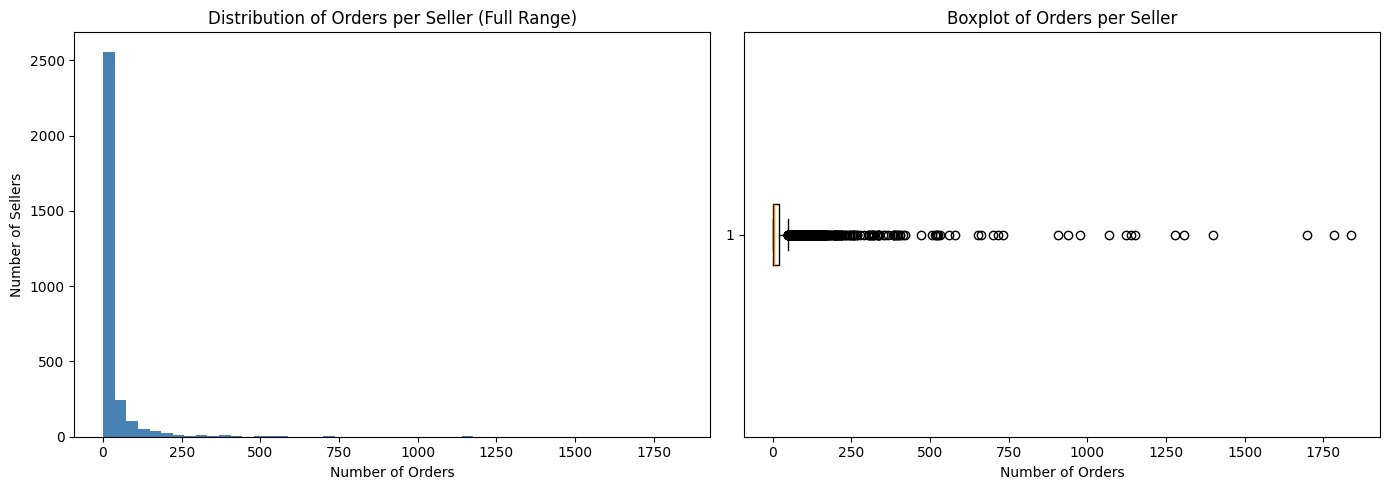

In [ ]:
# What does the distribution of seller order volume look like?

import pandas as pd
import matplotlib.pyplot as plt

# Get orders per seller (deduped so multi-item orders aren't double-counted)
per_seller_order = sellers_analysis_df.drop_duplicates(subset=["seller_id", "order_id"])
seller_order_counts = per_seller_order.groupby("seller_id")["order_id"].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(seller_order_counts, bins=50, color="steelblue")
axes[0].set_title("Distribution of Orders per Seller (Full Range)")
axes[0].set_xlabel("Number of Orders")
axes[0].set_ylabel("Number of Sellers")

axes[1].boxplot(seller_order_counts, vert=False)
axes[1].set_title("Boxplot of Orders per Seller")
axes[1].set_xlabel("Number of Orders")

plt.tight_layout()
plt.show()

**Analyst Commentary**

The seller's order volume is right-skewed (Median = 6 orders, 75th percentile = 21 orders, Maximum = 1838 orders), which suggests that a small number of sellers handle a disproportionately large number of orders.

The typical seller fulfills approximately 6 unique orders, has an average review score of 4.18, tends to deliver orders earlier than the estimated delivery date (median days_late = -11.93), and has no late deliveries.

The large gap between the 75th percentile (21 orders) and the maximum (1838 orders) indicates that order volume is highly concentrated among a relatively small number of sellers.


Because seller order volume is highly right-skewed, focusing on the top 10% of sellers targets those with the greatest customer impact while avoiding the many low-volume sellers whose performance would have limited influence on the overall customer experience.

**Business Rule 4:**

High-volume sellers are defined as the top 10% of sellers by unique orders fulfilled. This threshold is based on the highly right-skewed distribution of seller order volume and focuses the analysis on sellers with the greatest customer impact.

36 sellers meet the priority criteria; showing 20.
                             seller_id  unique_orders  avg_review_score  \
1029  54965bbe3e4f07ae045b90b0b8541f52             74          3.000000   
2000  a49928bcdf77c55c6d6e05e09a9b4ca5             98          3.010204   
1384  712e6ed8aa4aa1fa65dab41fed5737e4             78          3.384615   
1665  88460e8ebdecbfecb5f9601833981930            247          3.412955   
2453  cac4c8e7b1ca6252d8f20b2fc1a2e4af             74          3.527027   
333   1ca7077d890b907f89be8c954a02686a            114          2.333333   
2541  d20b021d3efdf267a402c402a48ea64b             89          3.685393   
2761  e5a3438891c0bfdb9394643f95273d8e            222          3.918919   
2492  cd68562d3f44870c08922d380acae552            124          3.943548   
207   11bfa66332777660bd0640ee84d47006             76          3.921053   
1280  6973a06f484aacf400ece213dbf3d946             94          3.563830   
801   431af27f296bc6519d890aa5a05fdb11           

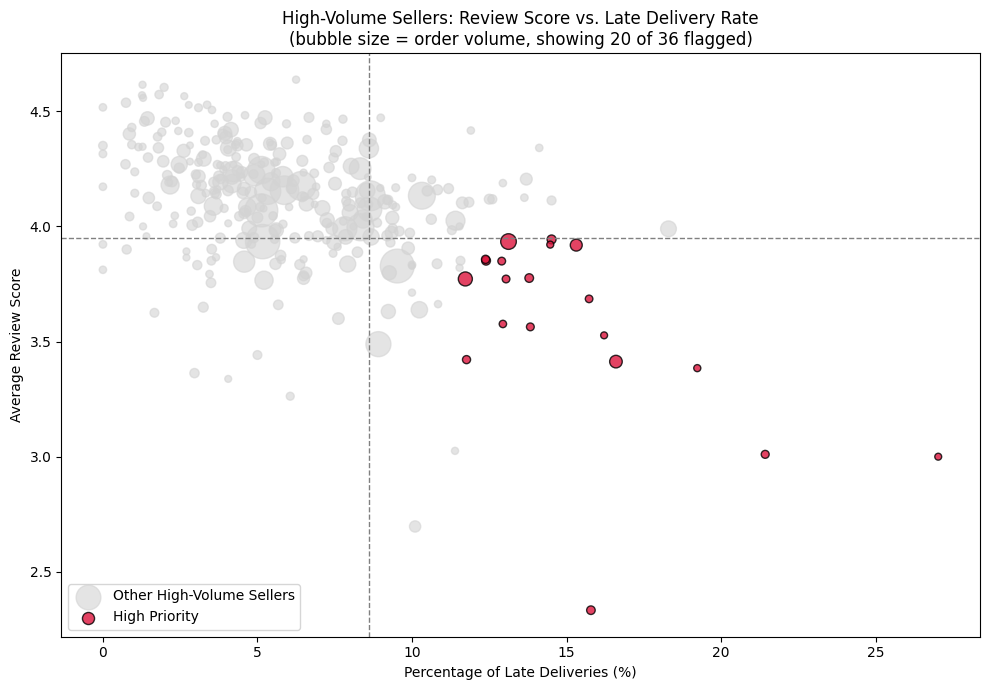

In [ ]:
# Among the high-volume sellers, which ones should Sarah prioritize?

import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Build seller-level summary (dedupe seller+order to avoid double-counting) ---
per_seller_order = sellers_analysis_df.drop_duplicates(subset=["seller_id", "order_id"]).copy()
per_seller_order["is_late"] = per_seller_order["days_late"] > 0

seller_summary = per_seller_order.groupby("seller_id").agg(
    unique_orders=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    pct_late_deliveries=("is_late", "mean")
).reset_index()
seller_summary["pct_late_deliveries"] = seller_summary["pct_late_deliveries"] * 100

# --- Step 2: Define high-volume tier (top 10% by order count) ---
volume_threshold = seller_summary["unique_orders"].quantile(0.90)
seller_summary["volume_tier"] = pd.cut(
    seller_summary["unique_orders"],
    bins=[0, volume_threshold, seller_summary["unique_orders"].max()],
    labels=["Standard", "High-Volume"]
)
high_volume = seller_summary[seller_summary["volume_tier"] == "High-Volume"].copy()

# --- Step 3: Flag underperformers — requires BOTH conditions (AND) ---
review_cutoff = high_volume["avg_review_score"].quantile(0.25)
late_cutoff = high_volume["pct_late_deliveries"].quantile(0.75)

high_volume["needs_attention"] = (
    (high_volume["avg_review_score"] < review_cutoff) &
    (high_volume["pct_late_deliveries"] > late_cutoff)
)

# --- Step 4: Get priority sellers — up to 20, but only as many as actually qualify ---
priority_sellers = high_volume[high_volume["needs_attention"]].sort_values(
    ["pct_late_deliveries", "avg_review_score"], ascending=[False, True]
)

max_display = 20
top_priority = priority_sellers.head(min(max_display, len(priority_sellers)))

print(f"{len(priority_sellers)} sellers meet the priority criteria; showing {len(top_priority)}.")
print(top_priority[["seller_id", "unique_orders", "avg_review_score", "pct_late_deliveries"]])

# --- Step 5: Visualize ---
fig, ax = plt.subplots(figsize=(10, 7))

other_hv = high_volume[~high_volume["seller_id"].isin(top_priority["seller_id"])]
ax.scatter(other_hv["pct_late_deliveries"], other_hv["avg_review_score"],
           s=other_hv["unique_orders"] / 3, color="lightgray", alpha=0.6,
           label="Other High-Volume Sellers")

ax.scatter(top_priority["pct_late_deliveries"], top_priority["avg_review_score"],
           s=top_priority["unique_orders"] / 3, color="crimson", alpha=0.8,
           edgecolor="black", label="High Priority")

ax.axvline(late_cutoff, color="gray", linestyle="--", linewidth=1)
ax.axhline(review_cutoff, color="gray", linestyle="--", linewidth=1)

ax.set_title(f"High-Volume Sellers: Review Score vs. Late Delivery Rate\n(bubble size = order volume, showing {len(top_priority)} of {len(priority_sellers)} flagged)")
ax.set_xlabel("Percentage of Late Deliveries (%)")
ax.set_ylabel("Average Review Score")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

**Analyst Commentary**

Thirty-six sellers meet the prioritization criteria indicated, but for Sarah's needs, the top 20 sellers have been identified for follow-up. The prioritized sellers generally exhibit below-average customer satisfaction together with elevated late-delivery rates, suggesting that fulfillment performance may be contributing to lower review scores. Because Sarah cannot operationally support every qualifying seller simultaneously, ranking sellers by business impact ensures that improvement efforts are concentrated where they have the greatest potential to improve customer satisfaction across the largest number of orders.

**Business Recommendation**

Focus operational improvement efforts on high-volume sellers exhibiting both below-average customer satisfaction and elevated late-delivery rates. This priortization allows Sarah to concentrate limited operational resources on sellers where improvements are likely to affect the largest number of customers.

**Questions for Further Investigation**

1. Which geographic regions experience the highest rates of late deliveries?

2. Within those regions, which product categories contribute most to those delays?

**Analyst Commentary**

This investigation established that delivery performance and customer satisfaction vary across sellers, providing one potential opportunity for operational improvement. However, Sarah cannot prioritize every improvement opportunity at the same time. The next investigation expands the analysis to the product-category level to determine which categories should be prioritized based on both customer satisfaction and business impact.